## Computational Finance Lab Assignment 1
### Constituent-Level Analysis: Volume, Volatility, Trend, and Option Pricing
#### Aleksandra Górska, Marcin Pałyga


## Libraries

In [204]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf
import warnings
import time
import re

from scipy.stats import norm
from scipy.optimize import brentq

warnings.filterwarnings('ignore')
sns.set_theme()

## Part A: Data ingestion

In [2]:
constituents = pd.read_csv('constituents-dax.csv')
dax_data = yf.download(constituents['Symbol'].to_list(), start='2020-01-01', end='2024-01-01', group_by='ticker')
dax_data.to_parquet('data/dax_data.parquet')

[*********************100%***********************]  40 of 40 completed


In [109]:
time_pd = 0
time_pl = 0
for i in range(100):
    start_pd = time.perf_counter()
    dax_data_pd = pd.read_parquet('data/dax_data.parquet')
    end_pd = time.perf_counter()
    time_pd += end_pd - start_pd

    start_pl = time.perf_counter()
    dax_data_pl = pl.read_parquet('data/dax_data.parquet')
    end_pl = time.perf_counter()
    time_pl += end_pl - start_pl

print(f"Average load time for pandas: {time_pd / 100:.4f} seconds")
print(f"Average load time for polars: {time_pl / 100:.4f} seconds")

Average load time for pandas: 0.0378 seconds
Average load time for polars: 0.0105 seconds


In [110]:
print(f"Polars memory usage: {dax_data_pl.estimated_size('mb'):.2f} MB")
print(f"Pandas memory usage: {dax_data_pd.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

Polars memory usage: 1.57 MB
Pandas memory usage: 1.57 MB


In [116]:
dax_data = pl.read_parquet('data/dax_data.parquet')
print(dax_data.shape)
dax_data.head()

(1021, 201)


"('HEN3.DE', 'Open')","('HEN3.DE', 'High')","('HEN3.DE', 'Low')","('HEN3.DE', 'Close')","('HEN3.DE', 'Volume')","('DHL.DE', 'Open')","('DHL.DE', 'High')","('DHL.DE', 'Low')","('DHL.DE', 'Close')","('DHL.DE', 'Volume')","('G24.DE', 'Open')","('G24.DE', 'High')","('G24.DE', 'Low')","('G24.DE', 'Close')","('G24.DE', 'Volume')","('RWE.DE', 'Open')","('RWE.DE', 'High')","('RWE.DE', 'Low')","('RWE.DE', 'Close')","('RWE.DE', 'Volume')","('BAS.DE', 'Open')","('BAS.DE', 'High')","('BAS.DE', 'Low')","('BAS.DE', 'Close')","('BAS.DE', 'Volume')","('DBK.DE', 'Open')","('DBK.DE', 'High')","('DBK.DE', 'Low')","('DBK.DE', 'Close')","('DBK.DE', 'Volume')","('CON.DE', 'Open')","('CON.DE', 'High')","('CON.DE', 'Low')","('CON.DE', 'Close')","('CON.DE', 'Volume')","('SY1.DE', 'Open')","('SY1.DE', 'High')",…,"('DTE.DE', 'Volume')","('CBK.DE', 'Open')","('CBK.DE', 'High')","('CBK.DE', 'Low')","('CBK.DE', 'Close')","('CBK.DE', 'Volume')","('MBG.DE', 'Open')","('MBG.DE', 'High')","('MBG.DE', 'Low')","('MBG.DE', 'Close')","('MBG.DE', 'Volume')","('MRK.DE', 'Open')","('MRK.DE', 'High')","('MRK.DE', 'Low')","('MRK.DE', 'Close')","('MRK.DE', 'Volume')","('MUV2.DE', 'Open')","('MUV2.DE', 'High')","('MUV2.DE', 'Low')","('MUV2.DE', 'Close')","('MUV2.DE', 'Volume')","('FRE.DE', 'Open')","('FRE.DE', 'High')","('FRE.DE', 'Low')","('FRE.DE', 'Close')","('FRE.DE', 'Volume')","('VNA.DE', 'Open')","('VNA.DE', 'High')","('VNA.DE', 'Low')","('VNA.DE', 'Close')","('VNA.DE', 'Volume')","('HNR1.DE', 'Open')","('HNR1.DE', 'High')","('HNR1.DE', 'Low')","('HNR1.DE', 'Close')","('HNR1.DE', 'Volume')",Date
f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,…,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,i64,datetime[ns]
78.805033,79.131239,78.25563,78.25563,460000,30.798813,31.25247,30.753447,31.1073,1.919948e6,52.927453,54.193013,52.927453,53.876621,160134,23.211238,23.287984,22.86162,22.989529,2370079,46.199485,47.05834,46.172002,46.920925,2025939,6.263928,6.586672,6.25317,6.586672,24048444,87.040945,89.154686,86.889962,87.871338,470236,87.866891,88.431829,…,9435019,5.161528,5.51307,5.161528,5.48238,14916915,28.56903,29.092357,28.485183,28.898638,2973654,97.83715,99.546296,97.421407,97.929535,613310,207.766417,210.610373,207.687414,210.057373,326933,44.019211,44.626554,43.922388,44.019211,1039427,29.924339,30.502221,29.874087,30.414282,1683124,140.537336,143.232115,140.129034,142.497177,131274,2020-01-02 00:00:00
77.689057,78.444484,77.431521,78.307137,459917,30.943983,30.96213,30.435885,30.667252,2.555879e6,53.560235,54.28341,53.469839,54.102615,157621,22.870148,22.887203,22.546113,22.887203,2593666,46.522419,46.604871,46.007106,46.2201,2579508,6.549916,6.596534,6.431576,6.499711,13519680,87.569383,87.569383,85.697207,86.044464,622871,87.320774,88.318838,…,9232877,5.42193,5.43216,5.360549,5.384729,7254038,28.710699,28.75696,28.019676,28.375307,4014262,97.929529,99.084358,97.09805,99.084358,529208,209.030397,209.504394,206.423427,207.450424,421465,43.763952,43.851975,43.341454,43.816765,1107601,30.414279,30.571313,30.250965,30.527344,1602053,141.517263,142.088883,140.70066,142.007217,98287,2020-01-03 00:00:00
77.963767,78.530342,77.448702,78.530342,442132,30.395056,30.567445,30.063885,30.508471,2.712666e6,53.741027,53.921821,53.379437,53.786224,111462,22.76782,22.818983,22.554638,22.554638,1773571,45.519277,45.62234,44.749742,45.533016,3487724,6.445024,6.449506,6.280066,6.441438,15053032,85.334853,85.334853,83.432483,85.063087,524571,87.452594,87.527921,…,7337533,5.310329,5.312189,5.141068,5.216399,8171528,27.950286,28.222067,27.603327,28.222067,3441396,98.761002,100.701114,97.606173,100.146797,635339,207.529434,208.003407,205.001468,207.529434,427462,43.240225,43.451477,42.778117,43.451477,854671,30.502217,30.615282,30.28237,30.433125,1340110,140.945641,141.680579,139.720737,141.35394

### Data Transformation

In [ ]:
metrics = ['Open', 'High', 'Low', 'Close', 'Volume']
dax_data = dax_data.rename({
    col: col.replace("(", "").replace(")", "").replace(", ", "_").replace("'", "")
    for col in dax_data.columns
})
dax_df_long = dax_data.melt(id_vars=['Date'], variable_name='Ticker_Metric', value_name='Value')
dax_df = dax_df_long.with_columns([
    pl.col('Ticker_Metric').str.split('_').alias('Split'),
]).with_columns([
    pl.col('Split').list.get(0).alias('Ticker'),
    pl.col('Split').list.get(1).alias('Metric'),
]).drop(['Split', 'Ticker_Metric'
        ]).pivot(values='Value', index=['Date', 'Ticker'], columns='Metric'
        ).sort(['Ticker', 'Date'])
print(dax_df.shape)
dax_df.head()

(40840, 7)


Date,Ticker,Open,High,Low,Close,Volume
datetime[ns],str,f64,f64,f64,f64,f64
2020-01-02 00:00:00,"""ADS.DE""",276.365612,280.235865,276.365612,278.611298,429314.0
2020-01-03 00:00:00,"""ADS.DE""",277.130088,279.280235,275.553319,278.993561,440067.0
2020-01-06 00:00:00,"""ADS.DE""",276.126737,277.751275,272.495359,276.795654,494435.0
2020-01-07 00:00:00,"""ADS.DE""",277.655691,283.341648,277.607922,281.669312,489629.0
2020-01-08 00:00:00,"""ADS.DE""",280.952569,289.409821,280.474759,289.409821,686646.0


## Part B: Per-stock metrics

In [118]:
dax_df = dax_df.with_columns([
    (pl.col('Close').log()-pl.col('Close').shift(1).log()).over('Ticker').alias('Log_Ret')
]).drop_nulls()
dax_df = dax_df.with_columns([
        (pl.col('Log_Ret').rolling_std(21).mul(np.sqrt(252))).over('Ticker').alias('Volatility_21d'),
        (pl.col('Close')*pl.col('Volume')).over('Ticker').alias('Turnover'),
        pl.col('Close').rolling_mean(50).over('Ticker').alias('MA_50'),
        pl.col('Close').rolling_mean(200).over('Ticker').alias('MA_200'),
        (pl.col('Close')/pl.col("Close").shift(63)-1).over('Ticker').alias('Momentum_63d')
    ]).drop_nulls()
print(dax_df.shape)
dax_df.head()

(32146, 13)


Date,Ticker,Open,High,Low,Close,Volume,Log_Ret,Volatility_21d,Turnover,MA_50,MA_200,Momentum_63d
datetime[ns],str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-10-14 00:00:00,"""ADS.DE""",273.498751,273.976561,270.918562,272.160858,251996.0,-0.005951,0.257914,6.8583e7,257.390795,237.905491,0.197645
2020-10-15 00:00:00,"""ADS.DE""",270.058515,270.727432,262.604653,264.707031,536244.0,-0.02777,0.271654,1.4195e8,258.015771,237.834059,0.143683
2020-10-16 00:00:00,"""ADS.DE""",266.522719,273.785446,266.236045,271.396393,552130.0,0.024957,0.282692,1.4985e8,258.677061,237.807062,0.151663
2020-10-19 00:00:00,"""ADS.DE""",271.874155,273.880965,270.536292,271.491913,305746.0,0.000352,0.282692,8.3008e7,259.256168,237.756175,0.159592
2020-10-20 00:00:00,"""ADS.DE""",271.39639,272.638686,268.720663,269.102905,263818.0,-0.008838,0.261685,7.0994e7,259.605926,237.654641,0.155993


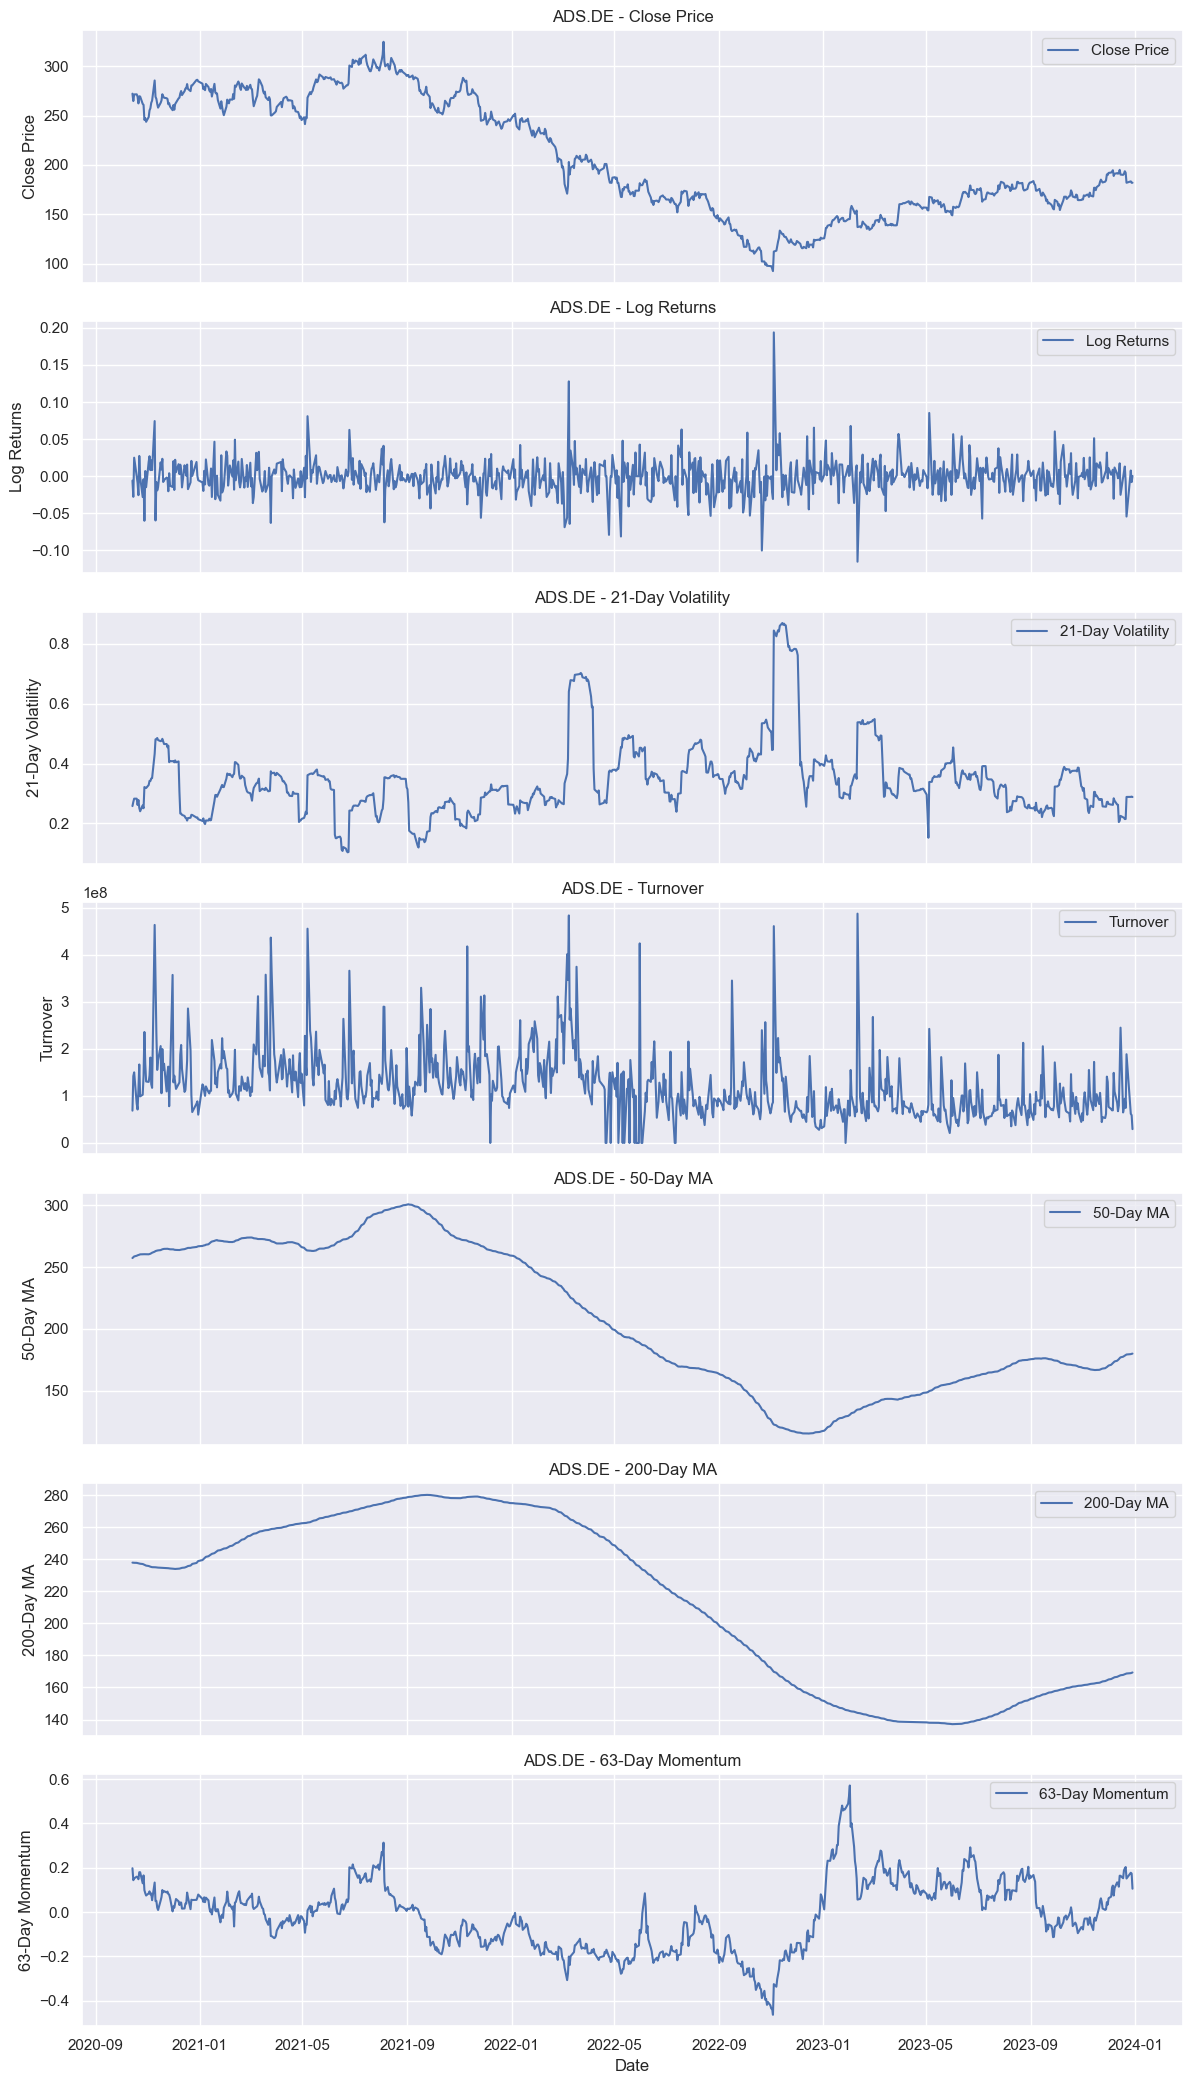

In [114]:
def plot_metrics_for_stock(ticker):
    stock_df = dax_df.filter(pl.col('Ticker') == ticker).to_pandas()
    metrics_to_plot = ['Close', 'Log_Ret', 'Volatility_21d', 'Turnover', 'MA_50', 'MA_200', 'Momentum_63d']
    name_of_metric = ['Close Price', 'Log Returns', '21-Day Volatility', 'Turnover', '50-Day MA', '200-Day MA', '63-Day Momentum']
    fig, axes = plt.subplots(len(metrics_to_plot), 1, figsize=(12, 3 * len(metrics_to_plot)), sharex=True)
    
    for ax, metric, name in zip(axes, metrics_to_plot, name_of_metric):
        ax.plot(stock_df['Date'], stock_df[metric], label=name)
        ax.set_title(f'{ticker} - {name}')
        ax.set_ylabel(name)
        ax.legend()
    
    plt.xlabel('Date')
    plt.tight_layout()
    plt.show()    
plot_metrics_for_stock('ADS.DE')

## Part C: Grouping and Top-K

### Polars and Pandas comparison

In [139]:
turnover_start = time.perf_counter()
turnover = (dax_df.sort(['Date', 'Turnover'], descending=[False, True])
            .group_by('Date')
            .head(10)
            .with_columns([
                pl.col('Turnover').rank('ordinal', descending=True).over('Date').alias('Rank')
            ])
            .select(['Date', 'Ticker', 'Turnover', 'Rank'])
            .pivot(values='Ticker', index='Date', columns='Rank'))
turnover_end = time.perf_counter()
turnover_pl = turnover_end - turnover_start
turnover

Date,1,2,3,4,5,6,7,8,9,10
datetime[ns],str,str,str,str,str,str,str,str,str,str
2020-10-14 00:00:00,"""BAYN.DE""","""SAP.DE""","""IFX.DE""","""ALV.DE""","""DTE.DE""","""SIE.DE""","""MBG.DE""","""BAS.DE""","""DHL.DE""","""VOW3.DE"""
2020-10-15 00:00:00,"""SAP.DE""","""BAYN.DE""","""SIE.DE""","""ALV.DE""","""BAS.DE""","""DTE.DE""","""MBG.DE""","""VOW3.DE""","""ADS.DE""","""DHL.DE"""
2020-10-16 00:00:00,"""MBG.DE""","""SAP.DE""","""BAYN.DE""","""ALV.DE""","""SIE.DE""","""ADS.DE""","""DTE.DE""","""BAS.DE""","""VOW3.DE""","""IFX.DE"""
2020-10-19 00:00:00,"""SAP.DE""","""ALV.DE""","""MBG.DE""","""SIE.DE""","""BAYN.DE""","""DTE.DE""","""ADS.DE""","""BAS.DE""","""IFX.DE""","""VOW3.DE"""
2020-10-20 00:00:00,"""SAP.DE""","""DTE.DE""","""SIE.DE""","""ALV.DE""","""BAYN.DE""","""DBK.DE""","""FRE.DE""","""MUV2.DE""","""FME.DE""","""DB1.DE"""
…,…,…,…,…,…,…,…,…,…,…
2023-12-21 00:00:00,"""SAP.DE""","""SIE.DE""","""BAS.DE""","""DTE.DE""","""ALV.DE""","""BAYN.DE""","""IFX.DE""","""VOW3.DE""","""CBK.DE""","""MBG.DE"""
2023-12-22 00:00:00,"""ADS.DE""","""SAP.DE""","""SIE.DE""","""BAYN.DE""","""DTE.DE""","""ALV.DE""","""MBG.DE""","""IFX.DE""","""DBK.DE""","""MUV2.DE"""
2023-12-27 00:00:00,"""SAP.DE""","""BAYN.DE""","""SIE.DE""","""DTE.DE""","""ALV.DE""","""MBG.DE""","""VOW3.DE""","""ADS.DE""","""MUV2.DE""","""IFX.DE"""


In [142]:
trending_start = time.perf_counter()
trending = (dax_df.with_columns(
    ((pl.col('MA_50')-pl.col('MA_200'))/pl.col('MA_200')).alias('Trend'))
    .sort(['Date', 'Trend'], descending=[False, True])
    .group_by('Date')
    .head(10)
    .with_columns([
        pl.col('Trend').rank('ordinal', descending=True).over('Date').alias('Rank')
    ])
    .select(['Date', 'Ticker', 'Trend', 'Rank'])
    .pivot(values='Ticker', index='Date', columns='Rank'))
trending_end = time.perf_counter()
trending_pl = trending_end - trending_start
trending

Date,1,2,3,4,5,6,7,8,9,10
datetime[ns],str,str,str,str,str,str,str,str,str,str
2020-10-14 00:00:00,"""ZAL.DE""","""DHL.DE""","""MBG.DE""","""IFX.DE""","""SY1.DE""","""G24.DE""","""BNR.DE""","""SIE.DE""","""VNA.DE""","""G1A.DE"""
2020-10-15 00:00:00,"""ZAL.DE""","""DHL.DE""","""MBG.DE""","""IFX.DE""","""SY1.DE""","""BNR.DE""","""G24.DE""","""SIE.DE""","""VNA.DE""","""G1A.DE"""
2020-10-16 00:00:00,"""ZAL.DE""","""DHL.DE""","""MBG.DE""","""IFX.DE""","""BNR.DE""","""SY1.DE""","""G24.DE""","""SIE.DE""","""VNA.DE""","""G1A.DE"""
2020-10-19 00:00:00,"""ZAL.DE""","""DHL.DE""","""MBG.DE""","""IFX.DE""","""BNR.DE""","""SY1.DE""","""G24.DE""","""SIE.DE""","""VNA.DE""","""G1A.DE"""
2020-10-20 00:00:00,"""ZAL.DE""","""DHL.DE""","""MBG.DE""","""IFX.DE""","""BNR.DE""","""SY1.DE""","""G24.DE""","""SIE.DE""","""VNA.DE""","""G1A.DE"""
…,…,…,…,…,…,…,…,…,…,…
2023-12-21 00:00:00,"""VNA.DE""","""DBK.DE""","""MUV2.DE""","""SAP.DE""","""HNR1.DE""","""RHM.DE""","""ADS.DE""","""ALV.DE""","""CBK.DE""","""G24.DE"""
2023-12-22 00:00:00,"""VNA.DE""","""DBK.DE""","""MUV2.DE""","""SAP.DE""","""HNR1.DE""","""RHM.DE""","""ADS.DE""","""ALV.DE""","""CBK.DE""","""BNR.DE"""
2023-12-27 00:00:00,"""VNA.DE""","""DBK.DE""","""MUV2.DE""","""SAP.DE""","""HNR1.DE""","""RHM.DE""","""ADS.DE""","""ALV.DE""","""CBK.DE""","""BNR.DE"""


In [145]:
df = dax_df.to_pandas()

turnover_start = time.perf_counter()
df_sorted = df.sort_values(by=['Date', 'Turnover'], ascending=[True, False])
df_sorted['Rank'] = df_sorted.groupby('Date')['Turnover'].rank(method='first', ascending=False).astype(int)
df_top10 = df_sorted[df_sorted['Rank'] <= 10]
turnover = df_top10.pivot(index='Date', columns='Rank', values='Ticker')
turnover_end = time.perf_counter()
turnover_pd = turnover_end - turnover_start

turnover

Rank,1,2,3,4,5,6,7,8,9,10
Date,,,,,,,,,,
2020-10-14,BAYN.DE,SAP.DE,IFX.DE,ALV.DE,DTE.DE,SIE.DE,MBG.DE,BAS.DE,DHL.DE,VOW3.DE
2020-10-15,SAP.DE,BAYN.DE,SIE.DE,ALV.DE,BAS.DE,DTE.DE,MBG.DE,VOW3.DE,ADS.DE,DHL.DE
2020-10-16,MBG.DE,SAP.DE,BAYN.DE,ALV.DE,SIE.DE,ADS.DE,DTE.DE,BAS.DE,VOW3.DE,IFX.DE
2020-10-19,SAP.DE,ALV.DE,MBG.DE,SIE.DE,BAYN.DE,DTE.DE,ADS.DE,BAS.DE,IFX.DE,VOW3.DE
2020-10-20,SAP.DE,DTE.DE,SIE.DE,ALV.DE,BAYN.DE,DBK.DE,FRE.DE,MUV2.DE,FME.DE,DB1.DE
...,...,...,...,...,...,...,...,...,...,...
2023-12-21,SAP.DE,SIE.DE,BAS.DE,DTE.DE,ALV.DE,BAYN.DE,IFX.DE,VOW3.DE,CBK.DE,MBG.DE
2023-12-22,ADS.DE,SAP.DE,SIE.DE,BAYN.DE,DTE.DE,ALV.DE,MBG.DE,IFX.DE,DBK.DE,MUV2.DE
2023-12-27,SAP.DE,BAYN.DE,SIE.DE,DTE.DE,ALV.DE,MBG.DE,VOW3.DE,ADS.DE,MUV2.DE,IFX.DE


In [146]:
df = dax_df.to_pandas()

trending_start = time.perf_counter()
df['Trend'] = (df['MA_50'] - df['MA_200']) / df['MA_200']
df_sorted = df.sort_values(by=['Date', 'Trend'], ascending=[True, False])
df_sorted['Rank'] = df_sorted.groupby('Date')['Trend'].rank(method='first', ascending=False).astype(int)
df_top10 = df_sorted[df_sorted['Rank'] <= 10]
trending = df_top10.pivot(index='Date', columns='Rank', values='Ticker')
trending_end = time.perf_counter()
trending_pd = trending_end - trending_start

trending

Rank,1,2,3,4,5,6,7,8,9,10
Date,,,,,,,,,,
2020-10-14,ZAL.DE,DHL.DE,MBG.DE,IFX.DE,SY1.DE,G24.DE,BNR.DE,SIE.DE,VNA.DE,G1A.DE
2020-10-15,ZAL.DE,DHL.DE,MBG.DE,IFX.DE,SY1.DE,BNR.DE,G24.DE,SIE.DE,VNA.DE,G1A.DE
2020-10-16,ZAL.DE,DHL.DE,MBG.DE,IFX.DE,BNR.DE,SY1.DE,G24.DE,SIE.DE,VNA.DE,G1A.DE
2020-10-19,ZAL.DE,DHL.DE,MBG.DE,IFX.DE,BNR.DE,SY1.DE,G24.DE,SIE.DE,VNA.DE,G1A.DE
2020-10-20,ZAL.DE,DHL.DE,MBG.DE,IFX.DE,BNR.DE,SY1.DE,G24.DE,SIE.DE,VNA.DE,G1A.DE
...,...,...,...,...,...,...,...,...,...,...
2023-12-21,VNA.DE,DBK.DE,MUV2.DE,SAP.DE,HNR1.DE,RHM.DE,ADS.DE,ALV.DE,CBK.DE,G24.DE
2023-12-22,VNA.DE,DBK.DE,MUV2.DE,SAP.DE,HNR1.DE,RHM.DE,ADS.DE,ALV.DE,CBK.DE,BNR.DE
2023-12-27,VNA.DE,DBK.DE,MUV2.DE,SAP.DE,HNR1.DE,RHM.DE,ADS.DE,ALV.DE,CBK.DE,BNR.DE


In [148]:
print(f"Turnover computation time for Polars: {turnover_pl:.4f}s and for Pandas: {turnover_pd:.4f}s")
print(f"Trending computation time for Polars: {trending_pl:.4f}s and for Pandas: {trending_pd:.4f}s")

Turnover computation time for Polars: 0.0130s and for Pandas: 0.0508s
Trending computation time for Polars: 0.0142s and for Pandas: 0.0414s


## Part D: Breadth and deciles

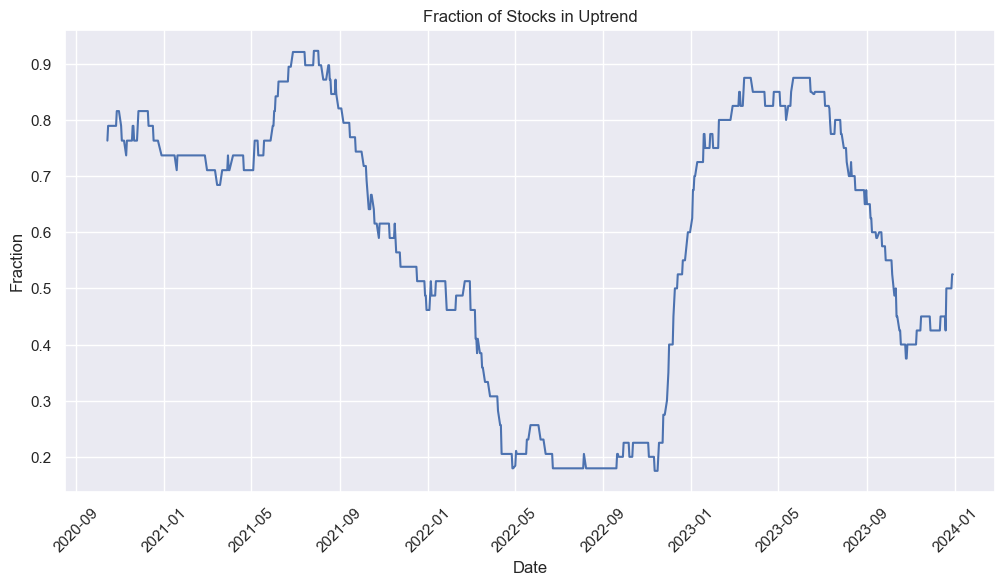

In [159]:
uptrend_fraction = (dax_df.with_columns(
    (pl.col('MA_50') > pl.col('MA_200')).alias('Uptrend'))
    .group_by('Date')
    .agg([
        (pl.col('Uptrend').sum() / pl.col('Uptrend').count()).alias('Uptrend_Fraction')
    ]).sort('Date'))
plt.figure(figsize=(12, 6))
plt.plot(uptrend_fraction['Date'], uptrend_fraction['Uptrend_Fraction'])
plt.xlabel('Date')
plt.ylabel('Fraction')
plt.title('Fraction of Stocks in Uptrend')
plt.xticks(rotation=45)
plt.show()

In [166]:
liquidity_deciles = (dax_df.group_by('Ticker')
    .agg(pl.col('Turnover').mean().alias('Avg_Turnover'))
        .sort('Avg_Turnover', descending=True)
    .with_columns(
        (pl.col('Avg_Turnover').rank('ordinal', descending=False)/pl.col('Avg_Turnover').count()).round(1).alias('Decile')
    ))
liquidity_deciles

Ticker,Avg_Turnover,Decile
str,f64,f64
"""SAP.DE""",2.2741e8,1.0
"""SIE.DE""",1.8182e8,1.0
"""ALV.DE""",1.7122e8,1.0
"""MBG.DE""",1.4870e8,0.9
"""BAYN.DE""",1.4110e8,0.9
…,…,…
"""BNR.DE""",2.4139e7,0.1
"""QIA.DE""",2.2374e7,0.1
"""HNR1.DE""",1.8145e7,0.1


In [187]:
median_volatility = (dax_df.join(liquidity_deciles.select(['Ticker', 'Decile']), on='Ticker')
    .group_by('Decile')
    .agg(pl.col('Volatility_21d').median().alias('Median_Volatility')).sort('Decile'))
median_volatility


Decile,Median_Volatility
f64,f64
0.0,0.238168
0.1,0.21001
0.2,0.228578
0.3,0.227982
0.4,0.281065
…,…
0.6,0.224555
0.7,0.255315
0.8,0.257534


In [180]:
median_momentum = (dax_df.join(liquidity_deciles.select(['Ticker', 'Decile']), on='Ticker')
    .group_by('Decile')
    .agg(pl.col('Momentum_63d').median().alias('Median_Momentum')).sort('Decile'))
median_momentum

Decile,Median_Momentum
f64,f64
0.0,0.006584
0.1,0.021961
0.2,0.018701
0.3,0.01723
0.4,-0.011517
…,…
0.6,0.008255
0.7,0.056937
0.8,0.010163


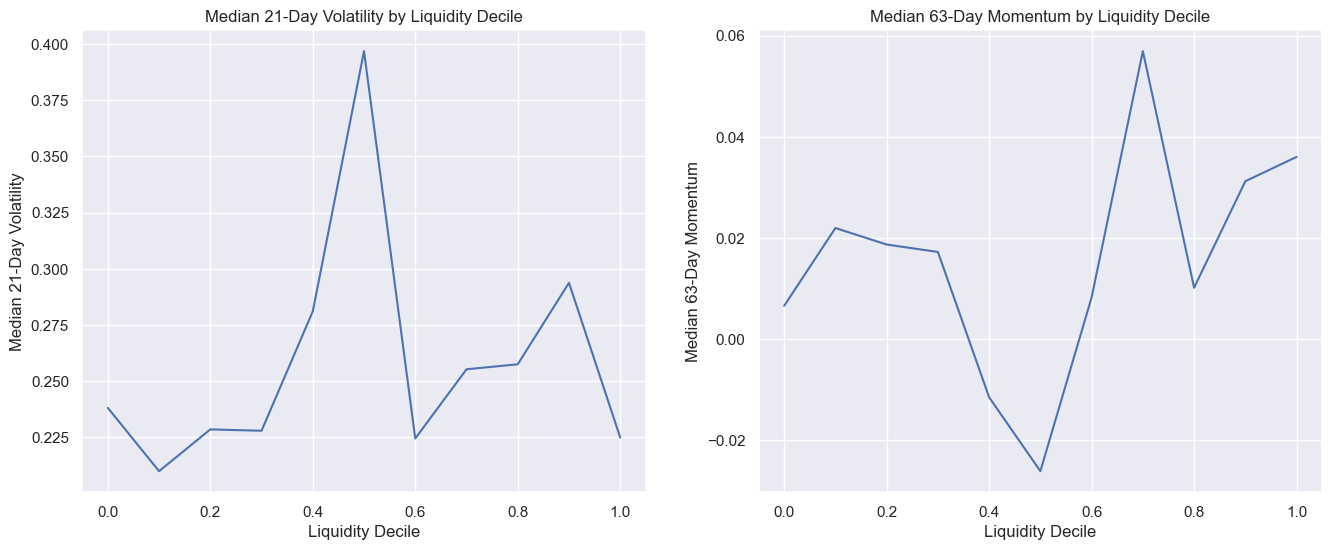

In [183]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(median_volatility['Decile'], median_volatility['Median_Volatility'])
ax1.set_xlabel('Liquidity Decile')
ax1.set_ylabel('Median 21-Day Volatility')
ax1.set_title('Median 21-Day Volatility by Liquidity Decile')
ax2.plot(median_momentum['Decile'], median_momentum['Median_Momentum'])
ax2.set_xlabel('Liquidity Decile')
ax2.set_ylabel('Median 63-Day Momentum')
ax2.set_title('Median 63-Day Momentum by Liquidity Decile')
plt.show()

## Part E: Option Pricing on selected stocks

In [191]:
top5_turnover_table = (dax_df.filter(pl.col('Date').dt.day() == 1)
                 .sort(['Date', 'Turnover'], descending=[False, True])
                 .group_by('Date')
                 .head(5)
                 .with_columns([
                     pl.col('Turnover').rank('ordinal', descending=True).over('Date').alias('Rank')
                 ])
                .select(['Date', 'Ticker', 'Turnover', 'Rank'])
                .pivot(values='Ticker', index='Date', columns='Rank'))
top5_turnover_table

Date,1,2,3,4,5
datetime[ns],str,str,str,str,str
2020-12-01 00:00:00,"""SAP.DE""","""VOW3.DE""","""SIE.DE""","""ALV.DE""","""IFX.DE"""
2021-02-01 00:00:00,"""SAP.DE""","""IFX.DE""","""SIE.DE""","""ADS.DE""","""ALV.DE"""
2021-03-01 00:00:00,"""SAP.DE""","""BAYN.DE""","""IFX.DE""","""ALV.DE""","""SIE.DE"""
2021-04-01 00:00:00,"""SAP.DE""","""SIE.DE""","""MBG.DE""","""DTE.DE""","""BAYN.DE"""
2021-06-01 00:00:00,"""VOW3.DE""","""SAP.DE""","""SIE.DE""","""MBG.DE""","""ADS.DE"""
…,…,…,…,…,…
2023-06-01 00:00:00,"""ALV.DE""","""SAP.DE""","""SIE.DE""","""IFX.DE""","""DTE.DE"""
2023-08-01 00:00:00,"""SIE.DE""","""BMW.DE""","""DHL.DE""","""MBG.DE""","""SAP.DE"""
2023-09-01 00:00:00,"""VOW3.DE""","""MBG.DE""","""SIE.DE""","""SAP.DE""","""BMW.DE"""


In [197]:
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = (np.log(S / K) + (r - 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))

In [211]:
top5_turnover = (dax_df.filter(pl.col('Date').dt.day() == 1)
                 .sort(['Date', 'Turnover'], descending=[False, True])
                 .group_by('Date')
                 .head(5)
                 .with_columns([
                     pl.col('Turnover').rank('ordinal', descending=True).over('Date').alias('Rank')
                 ])
                .select(['Date', 'Ticker', 'Volatility_21d', 'Close']))
top5_turnover = top5_turnover.with_columns([
    pl.Series("ATM_Call_30d", 
               bs_call(
                   S=top5_turnover['Close'].to_numpy(),
                   K=top5_turnover['Close'].to_numpy(),
                   T=30/252,
                   r=0.00,
                   sigma=top5_turnover['Volatility_21d'].to_numpy()
               ))
])    
top5_turnover

Date,Ticker,Volatility_21d,Close,ATM_Call_30d
datetime[ns],str,f64,f64,f64
2020-12-01 00:00:00,"""SAP.DE""",0.247202,93.233727,3.171488
2020-12-01 00:00:00,"""VOW3.DE""",0.433711,94.871277,5.658493
2020-12-01 00:00:00,"""SIE.DE""",0.327768,98.759872,4.453343
2020-12-01 00:00:00,"""ALV.DE""",0.399719,156.778748,8.619221
2020-12-01 00:00:00,"""IFX.DE""",0.317978,28.193565,1.233389
…,…,…,…,…
2023-12-01 00:00:00,"""SAP.DE""",0.134734,143.569641,2.662384
2023-12-01 00:00:00,"""SIE.DE""",0.230261,148.213699,4.696393
2023-12-01 00:00:00,"""ALV.DE""",0.122744,214.100693,3.617077


In [206]:
def inverse_bs_call(C, S, K, T, r):

    def objective_function(sigma):
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        price = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
        return price - C

    try:
        implied_vol = brentq(objective_function, 1e-6, 5.0)
    except ValueError:
        implied_vol = np.nan
    return implied_vol

In [212]:
top5_turnover = top5_turnover.with_columns([
    pl.Series("Implied_Vol_30d", 
        [inverse_bs_call(
            C=c,
            S=s,
            K=s,
            T=30/252,
            r=0.00
        ) for c, s in zip(top5_turnover['ATM_Call_30d'], top5_turnover['Close'])])
])
top5_turnover = top5_turnover.with_columns(
    (pl.col('Implied_Vol_30d') - pl.col('Volatility_21d')).alias('Error')).select(['Date', 'Ticker', 'ATM_Call_30d', 'Volatility_21d', 'Implied_Vol_30d', 'Error'])
top5_turnover

Date,Ticker,ATM_Call_30d,Volatility_21d,Implied_Vol_30d,Error
datetime[ns],str,f64,f64,f64,f64
2020-12-01 00:00:00,"""SAP.DE""",3.171488,0.247202,0.247202,7.7716e-16
2020-12-01 00:00:00,"""VOW3.DE""",5.658493,0.433711,0.433711,8.9373e-15
2020-12-01 00:00:00,"""SIE.DE""",4.453343,0.327768,0.327768,7.2164e-16
2020-12-01 00:00:00,"""ALV.DE""",8.619221,0.399719,0.399719,3.8858e-15
2020-12-01 00:00:00,"""IFX.DE""",1.233389,0.317978,0.317978,6.1062e-16
…,…,…,…,…,…
2023-12-01 00:00:00,"""SAP.DE""",2.662384,0.134734,0.134734,2.2204e-16
2023-12-01 00:00:00,"""SIE.DE""",4.696393,0.230261,0.230261,-3.3307e-16
2023-12-01 00:00:00,"""ALV.DE""",3.617077,0.122744,0.122744,-5.4123e-16
